Function to learn :

$$ y(x) = e^x\sin x $$

Guiding ode : 

$$ \dfrac{dy}{dx} = e^x(\sin x + \cos x) $$

with the IC :

$$ y(0) = 0 $$

In [77]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [78]:
# domain
N = 101
x = torch.linspace(-4.0,4.0,N,requires_grad=True).reshape(-1,1)

In [79]:
# Building the model
model = nn.Sequential(
    nn.Linear(1,20),
    nn.Tanh(),
    nn.Linear(20,20),
    nn.Tanh(),
    nn.Linear(20,1)
)

In [80]:
# Loss function
def Loss(model,x):
    y = model(x)

    # IC loss
    loss_IC = (y[N//2])**2

    # ODE Loss
    dydx = torch.autograd.grad(
        outputs=y,
        inputs=x,
        grad_outputs=torch.ones_like(y),
        create_graph=True
    )[0]
    loss_ODE = torch.mean((dydx - torch.exp(x)*(torch.sin(x) + torch.cos(x)))**2)

    # return total loss
    return loss_IC + loss_ODE

In [81]:
# optimizer
optim = torch.optim.Adam(model.parameters(),lr = 0.01)

In [82]:
# training
N_epochs = 10000
loss_arr = []
for epoch in range(N_epochs):
    # forward pass and loss
    loss = Loss(model,x)
    loss_arr.append(loss.item())

    # optimization
    loss.backward()
    optim.step()
    optim.zero_grad()

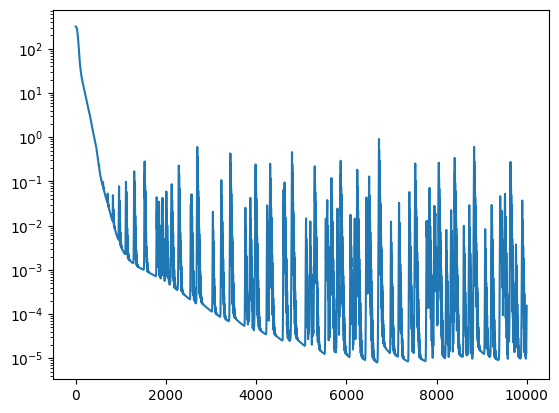

In [83]:
# loss plot
plt.semilogy(loss_arr)
plt.show()

In [ ]:
# exact function
y_exact = torch.exp(x)*torch.sin(x)

# PINN function
with torch.no_grad():
    y_PINN = model(x)

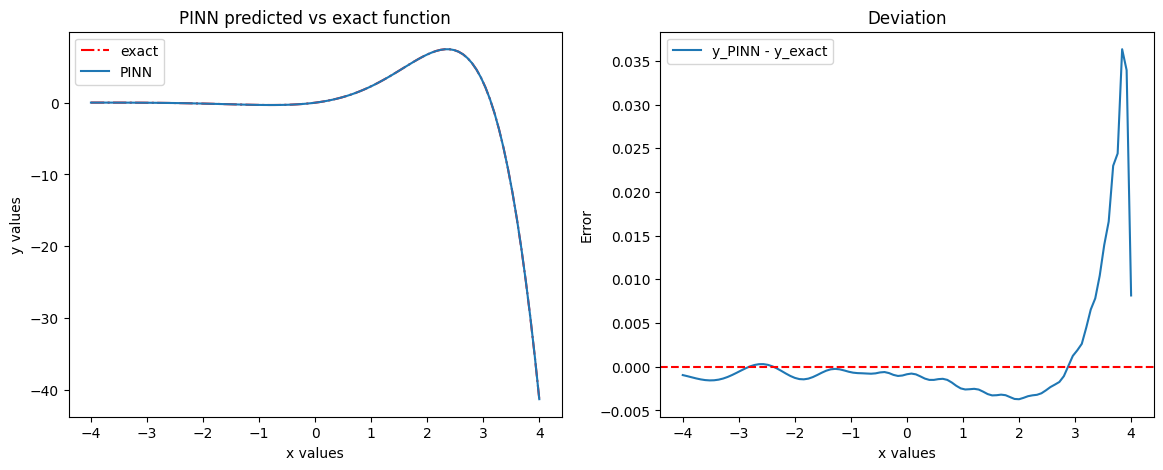

In [85]:
# comparing the PINN against the exact function
plt.figure(figsize = (14,5))

plt.subplot(1,2,1)
plt.plot(x.flatten().detach(),y_exact.flatten().detach(),c = 'red',ls = '-.',label = 'exact')
plt.plot(x.flatten().detach(),y_PINN.flatten().detach(),label = 'PINN')
plt.legend()
plt.title("PINN predicted vs exact function")
plt.xlabel("x values")
plt.ylabel("y values")

plt.subplot(1,2,2)
plt.plot(x.flatten().detach(),(y_PINN-y_exact).flatten().detach(),label = f'y_PINN - y_exact')
plt.axhline(0,ls = '--',c = 'red')
plt.legend()
plt.title("Deviation")
plt.xlabel("x values")
plt.ylabel("Error")
plt.show()

### Remarks :

1. SGD (Stochastic Gradient Descent) optimizer performs poorly.
2. Adam optimizer performs way better (usually the first choice for PINNs).
3. Try with different optimizers : SGD, SGD with momentum, Adam etc.